# Adjoint Optimization of a Multi-Patch Antenna

In this notebook, we build on the [single patch antenna optimization](https://www.flexcompute.com/tidy3d/examples/notebooks/RFAutograd1RectangularPatchAntenna/) to demonstrate a more complex and realistic use of inverse design. While the simple rectangular patch primarily involves tuning two parameters (width and height), real-world antenna design often requires juggling many more degrees of freedom to achieve advanced performance targets like dual-band operation.

Here, we expand the design space significantly. The antenna now features a central patch with an optimizable inset at the feed connection, fin structures on the top edge, and passive radiating elements that couple to the central patch. Instead of 2 parameters, the optimizer now simultaneously tunes 18 dimensions, including the sizes and positions of all structures. The goal is to achieve resonance and impedance matching at two target frequencies.

This notebook reuses the same core simulation and objective function infrastructure from the first notebook but applies it to a much richer design space where traditional parameter sweeps would be impractical. The adjoint method makes this high-dimensional optimization tractable by efficiently computing gradients with respect to all parameters in just two simulations per iteration.

<div style="display: flex; gap: 10px; justify-content: center;">
    <img src="img/rf_autograd_2_patch_antenna_thumbnail.png" style="height:500px; object-fit: contain;"/>
</div>

In [1]:
import os
import pickle

import autograd.numpy as anp
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import optax
import tidy3d as td
import tidy3d.plugins.smatrix as smatrix
from autograd import value_and_grad
from rich.console import Console
from rich.text import Text
from tidy3d.plugins.microwave import rf_material_library
from tidy3d.web import run

# Setup console and printing parameters for rich printing during optimization loops
console = Console()
print_decimal_places = 2  # how many decimal places to use in printing
print_iteration_frequency = 5  # how often to print optimization progress

08:16:26 EST WARNING: Using canonical configuration directory at                
             '/Users/gregoryroberts/.config/tidy3d'. Found legacy directory at  
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

BroadbandModeABCFitterParam(max_num_poles=5, tolerance_rms=1e-06, frequency_sampling_points=15)

ModeSpec(
    num_modes=1,
    target_neff=None,
    num_pml=(0, 0),
    filter_pol=None,
    angle_theta=0.0,
    angle_phi=0.0,
    precision='double',
    bend_radius=None,
    bend_axis=None,
    angle_rotation=False,
    track_freq=None,
    group_index_step=False,
    sort_spec=ModeSortSpec(
        filter_key=None,
        filter_reference=0.0,
        filter_order='over',
        bounding_box=None,
        keep_modes='all',
        sort_key='n_eff',
        sort_reference=None,
        sort_order='descending',
        track_freq='central'
    ),
    interp_spec=None
)

PMLParams(
    sigma_order=3,
    sigma_min=0.0,
    sigma_max=1.5,
    kappa_order=3,
    kappa_min=1.0,
    kappa_max=3.0,
    alpha_order=1,
    alpha_min=0.0,
    alpha_max=0.0
)

PMLParams(
    sigma_order=3,
    sigma_min=0.0,
    sigma_max=1.0,
    kappa_order=3,
    kappa_min=1.0,
    kappa_max=5.0,
    alpha_order=1,
    alpha_min=0.0,
    alpha_max=0.9
)

...

ChargeToleranceSpec(abs_tol=10000000000.0, rel_tol=1e-10, max_iters=30, ramp_up_iters=1)

ChargeToleranceSpec(abs_tol=10000000000.0, rel_tol=1e-10, max_iters=30, ramp_up_iters=1)

ChargeToleranceSpec(abs_tol=10000000000.0, rel_tol=1e-10, max_iters=30, ramp_up_iters=1)

FixedAngleSpec()

PECFrame(length=2)

## Configuration and Parameters

We set up the parameters for the multi-patch optimization, including the dual-band target frequencies and substrate geometry. The substrate is larger than in the single patch case to accommodate the passive radiating elements on either side of the central patch. As before, we use a scaling factor to convert Tidy3D's default unit of micrometers to millimeters (mm).

In [2]:
# length scales and geometric parameters for optimization
mm = 1e3  # mm scaling

# feedline parameters
feed_x = 2.46 * mm  # width of feed
feed_y = 20 * mm  # length of feed
feed_offset = 2.09 * mm  # feed offset from center of patch

# substrate geometric parameters - sized to support the multi-patch antenna geometry
sub_width = 3 * 23.34 * mm
sub_height_extension = 1.75 * 25 * mm

sub_x = [-0.5 * sub_width, 0.5 * sub_width]
sub_y = [-feed_y, sub_height_extension]
sub_z = 0.68 * mm

# center and size for placing directivity and far field monitors to capture radiation from the
# antenna patch
directivity_center_x = np.mean(sub_x)
directivity_center_y = np.mean(sub_y)
directivity_size_x = 5 * mm + sub_x[1] - sub_x[0]
directivity_size_y = 5 * mm + sub_y[1] - sub_y[0]

# frequency range (Hz) for simulating
freq_start = 7e9
freq_stop = 11e9
# simulation frequencies to cover enough bandwidth for evaluating and optimizing antennas
opt_sim_freqs = [8e9, 10e9]

freq0 = 0.5 * (freq_start + freq_stop)  # central frequency
wavelength0 = td.C_0 / freq0  # wavelength of central frequency in vacuum

# frequencies for computing S-parameters of antennas
freqs_s_params = np.linspace(freq_start, freq_stop, 200)

# optimize multi patch geometry for dual resonance
num_opt_freqs = 2
opt_freqs = np.linspace(8e9, 9e9, num_opt_freqs)

# set ranges of theta and phi to record directivity for
theta_directivity = np.linspace(-np.pi, np.pi, 201)
phi_directivity = np.linspace(0, np.pi, 101)

# set the optimization theta, phi grid for enhancing directivity around theta=0
num_theta_opt_points = 12
theta_opt = theta_directivity[
    (len(theta_directivity) // 2) - (num_theta_opt_points // 2) : (len(theta_directivity) // 2)
    + (num_theta_opt_points // 2)
    + 1
]
phi_opt = phi_directivity  # use the full phi sweep, but limit the theta points to be centered around 0 degrees

# materials for optimization
air = td.Medium()  # set up the antennas so they radiate into air
# choose common PCB material, ArlonAD255C, from the RF material library to use as substrate
sub_medium = rf_material_library["AD255C"]["design"]
PEC = td.PEC2D  # thickness-free PEC medium for antenna patches, feed lines, and the ground plane

## Create Simulation Objects

To prepare for the optimization, we need to make a base simulation that we can add the antenna geometry and excitation source to. This base simulation includes the ground plane and substrate, the two structures below the patch antenna. In this simulation, we also set up `LayerRefinementSpec` objects around our ground, substrate, and patch antenna layers. The fine mesh improves accuracy of both the simulation and PEC gradients. As in other RF examples, the source will be added later via a `LumpedPort`.

In [3]:
def create_base_sim():
    """
    Creates the base simulation for evaluating and optimizing patch antennas. The base simulation includes the
    substrate geometry, and ground plane. It also overrides a vertical slice of the simulation where the feed and
    patch will be placed with a fine mesh override to ensure accurate simulation and gradients near the PEC boundaries.
    """
    substrate_box = td.Box.from_bounds(
        [sub_x[0], sub_y[0], -sub_z / 2.0],
        [sub_x[1], sub_y[1], sub_z / 2.0],
    )
    # Define substrate structure
    substrate = td.Structure(
        geometry=substrate_box,
        medium=sub_medium,
    )

    # Define ground plane structure and assign the material by PEC
    ground_plane = td.Structure(
        geometry=substrate_box.updated_copy(
            center=list(substrate_box.center[0:2]) + [-sub_z / 2.0],
            size=list(substrate_box.size[0:2]) + [0],
        ),
        medium=PEC,
    )

    # list of structures for the simulation arranged first by dielectric and then PEC to
    # ensure PEC takes precedence at interfaces.
    structures_list = [substrate, ground_plane]

    # PML wavelength at 10 GHz
    wl_pml = wavelength0

    # quarter wavelength (at 10 GHz) padding on each side
    sim_x_size = sub_x[1] - sub_x[0] + wl_pml / 2.0
    sim_y_size = sub_y[1] - sub_y[0] + wl_pml / 2.0
    sim_y_center = np.mean(sub_y)

    sim_z_max = sub_z + 1.5 * wavelength0
    sim_z_min = sub_z - 0.5 * wavelength0
    sim_z_center = 0.5 * (sim_z_max + sim_z_min)
    sim_z_size = sim_z_max - sim_z_min

    # set a fine mesh for the corner refinement based on the center wavelength
    dl = wavelength0 / 200.0
    mesh_override_vertical_padding = 1 * mm

    layer_refinement_ground = td.LayerRefinementSpec.from_structures(
        axis=2, min_steps_along_axis=3, structures=[ground_plane]
    )

    layer_refinement_patch = td.LayerRefinementSpec(
        center=(0, sim_y_center, sub_z / 2),
        size=(td.inf, td.inf, mesh_override_vertical_padding),
        axis=2,
        min_steps_along_axis=3,
        corner_refinement=td.GridRefinement(dl=dl, num_cells=3),
    )

    layer_refinement_substrate = td.LayerRefinementSpec.from_structures(
        axis=2, structures=[substrate], min_steps_along_axis=3
    )

    # Truncate the computational domain by PMLs
    boundary_spec = td.BoundarySpec(
        x=td.Boundary.pml(),
        y=td.Boundary.pml(),
        z=td.Boundary.pml(),
    )

    # Create the simulation object
    base_sim = td.Simulation(
        center=[0.0, sim_y_center, sim_z_center],
        size=[sim_x_size, sim_y_size, sim_z_size],
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=20,  # largest cell size is set to 20 cells per smallest wavelength.
            wavelength=td.C_0 / freq_stop,  # smallest wavelength to resolve
            layer_refinement_specs=[
                layer_refinement_ground,
                layer_refinement_substrate,
                layer_refinement_patch,
            ],
        ),
        structures=structures_list,
        sources=[],  # sources will be added by TerminalComponentModeler
        monitors=[],
        run_time=70 * (substrate.geometry.size[1] / td.C_0),
        boundary_spec=boundary_spec,
        plot_length_units="mm",  # this option will make plots default to units of millimeters.
    )

    return base_sim

In addition to the base simulation creation, we set up a function to add a feed line and PEC patches to a simulation object. Later, this will allow us to create an antenna with an arbitrary list of patches and insert it into our base simulation.

In [4]:
def create_simulation_with_patches(base_sim, patch_boxes, monitors):
    """
    Creates a new simulation from the base simulation that includes PEC patches for all of the Box
    objects in patch_boxes as well as adds a feed line.
    """
    patches = []
    for patch_box in patch_boxes:
        patches.append(td.Structure(geometry=patch_box, medium=PEC))

    feed_geometry = td.Box.from_bounds(
        [feed_offset - 0.5 * feed_x, -feed_y, sub_z / 2], [feed_offset + 0.5 * feed_x, 0, sub_z / 2]
    )

    feed = td.Structure(geometry=feed_geometry, medium=PEC)

    return base_sim.updated_copy(
        structures=list(base_sim.structures) + [feed] + patches,
        monitors=list(base_sim.monitors) + monitors,
    )

Finally, we set up a function to create a `LumpedPort` and `TerminalComponentModeler` that will generate the input excitation to the antenna. We can specify an impedance for the port as well as the desired frequencies for the resulting simulation. The `TerminalComponentModeler` will set up the simulations we need to evaluate and optimize the antenna.

In [5]:
def create_modeler(simulation, frequencies, radiation_monitors=(), port_impedance=50):
    """
    Creates the LumpedPort and TerminalComponentModeler based on a `simulation`, the desired
    simulation `frequencies`, `radiation_monitors` for computing directivity, and a `port_impedance`.
    """
    # Setup a LumpedPort for the TerminalComponentModeler, which is needed
    # to end the port with a matched load as well as providing a source for the simulation.
    port = smatrix.LumpedPort(
        center=[feed_offset, -feed_y, 0],
        size=[feed_x, 0, sub_z],
        voltage_axis=2,
        name="lumped_port",
        impedance=port_impedance,
    )

    # We integrate the base simulation with the LumpedPort using the TerminalComponentModeler.
    # This allows us to compute scattering parameters and extract any additional data needed from the simulation.
    modeler = smatrix.TerminalComponentModeler(
        simulation=simulation,
        ports=[port],
        freqs=frequencies,
        remove_dc_component=False,  # include DC component for more accuracy at low frequencies
        radiation_monitors=radiation_monitors,
    )

    return modeler

## Setup Plotting and Evaluation Functions

Here, we set up helper functions for plotting and evaluating antenna performance. These are largely the same as in the first notebook. **Note: the plotting functions below are useful for visualizations in this notebook, but their internals are not crucial to the understanding of how to set up and run gradient based RF optimizations in tidy3d. Feel free to skim this section and skip to the next section whenever you're ready.**

In [6]:
def plot_structures_and_mesh(patch_boxes):
    """Plots the antenna structure and surrounding mesh to ensure it looks as expected before running simulations."""
    base_sim = create_base_sim()

    no_additional_monitors = []
    sim_with_patches = create_simulation_with_patches(base_sim, patch_boxes, no_additional_monitors)

    fig, ax = plt.subplots()

    # examine the structure and mesh in the x-y plane
    sim_with_patches.plot(
        z=sub_z / 2,
        ax=ax,
        monitor_alpha=0.2,
    )
    sim_with_patches.plot_grid(z=sub_z / 2, ax=ax)

    plt.show()

We set up a function that can calculate `S11` and realized antenna gain for each polarization. `S11` is the voltage reflection coefficient and $|S_{11}|^2$ is the power reflection coefficient or in other words, the reflected power divided by the input power. A good antenna will have a small `S11` at its operating frequencies. In the realized gain plot, we can see how efficiently energy is radiating from the antenna and in what direction when compared to an isotropic radiator.

In [7]:
def evaluate_antenna(patch_params, eval_s_params_freqs):
    """
    Evaluate the S11 parameter and realized gain in both polarizations for the given antenna geometry.
    The S11 is calculated across a broad spectrum while the realized gain is only computed for the opt_freqs.
    """
    patch_boxes = params_to_boxes(patch_params)

    base_sim = create_base_sim()
    no_additional_monitors = []
    sim_with_patches = create_simulation_with_patches(base_sim, patch_boxes, no_additional_monitors)

    monitor_directivity = td.DirectivityMonitor(
        center=[directivity_center_x, directivity_center_y, 0],
        size=(
            directivity_size_x,
            directivity_size_y,
            4 * mm,
        ),
        freqs=opt_freqs,
        name="directivity",
        phi=list(phi_directivity),
        theta=list(theta_directivity),
        far_field_approx=True,
    )

    # we only need whatever frequencies are unique in these two lists to have all the data we need for computing
    # S11 and gain
    eval_freqs = np.unique(list(eval_s_params_freqs) + list(opt_freqs))

    modeler = create_modeler(sim_with_patches, eval_freqs, radiation_monitors=[monitor_directivity])
    smatrix_data = run(modeler, task_name="smatrix", verbose=False)

    antenna_parameters_freq = smatrix_data.get_antenna_metrics_data(monitor_name="directivity")
    partial_realized_gain = antenna_parameters_freq.partial_realized_gain(pol_basis="linear")

    return smatrix_data, partial_realized_gain

Given the optimization results, we can plot the comparison of two antenna simulations using the `plot_antenna_comparison` function below. We can easily compare the initial and final optimization states to see how well the resulting antenna is performing in our desired metrics. During the optimization, we will also periodically save the `S11` and gain of the antenna. The function `plot_antenna_evolution` allows us to plot these metrics out so we can see how performance evolved over the course of the optimization.

In [8]:
def plot_antenna_comparison(
    s_matrix_list,
    sim_data_list,
    partial_realized_gain_list,
    plot_phi,
    plot_title="Antenna Simulation Comparison",
    sim_names=None,
    single_color_gain_plots=False,
    savefig_fname=None,
):
    """
    Plots a comparison of two sets of simulation data.

    Args:
        s_matrix_list: List of S-matrix objects [s_matrix_sim1, s_matrix_sim2].
        sim_data_list: List of sim_data objects [sim_data_sim1, sim_data_sim2],
                       where each sim_data contains a "radiation" DirectivityMonitor output.
        partial_realized_gain_list: List of realized gain in linear polarization for each simulation.
        plot_phi: The phi value to select in the realized gain data for plotting.
        plot_title: Optional title to specify for plot (default is "Antenna Simulation Comparison").
        sim_names: Optional list of names for simulations for clearer legends.
        single_color_gain_plots: Optional choice to use a single color for all the frequencies
                                 in the gain plot (True) or have each frequency a different
                                 color (False). Default is False.
        savefig_fname: An optional filename to save the resulting figure
    """

    num_simulations = len(s_matrix_list)
    if num_simulations != 2 or len(sim_data_list) != 2:
        print("Warning: This function is designed to compare exactly two simulations.")

    alphas = [0.5, 1.0]  # Alpha for sim1, sim2
    if sim_names is None or len(sim_names) != num_simulations:
        sim_names = [f"Sim {i + 1}" for i in range(num_simulations)]

    grid_spec_cols = 3  # S11 and realized gain for each polarization side-by-side
    fig_width = grid_spec_cols * 4.5
    fig_height = 6.5

    num_rows = 1

    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
    gs = fig.add_gridspec(num_rows, grid_spec_cols)
    axs_list = []

    # plot the S11 parameter comparison for each simulation
    ax_s11 = fig.add_subplot(gs[0, 0])
    axs_list.append(ax_s11)
    ax_s11.set_title("$S_{11}$ Coefficient")
    ax_s11.set_xlabel("Frequency (GHz)")
    ax_s11.set_ylabel("$|S_{11}|^2$ (dB)")

    for sim_idx in range(num_simulations):
        s_matrix = s_matrix_list[sim_idx]
        current_alpha = alphas[sim_idx]
        sim_label_name = sim_names[sim_idx]

        s11_freqs_ghz = s_matrix.data.coords["f"] / 1e9
        s11_data_selection = s_matrix.data.isel(port_out=0, port_in=0)

        s11_values_flat = s11_data_selection.values.flatten()
        s11_values_db = 20 * np.log10(np.abs(s11_values_flat))
        ax_s11.plot(
            s11_freqs_ghz,
            s11_values_db,
            alpha=current_alpha,
            label=f"{sim_label_name})",
        )

    for opt_freq in opt_freqs:
        ax_s11.axvline(x=opt_freq / 1e9, color="k", linestyle="--")

    ax_s11.set_ylim(-25, 2)
    ax_s11.grid(True)
    ax_s11.legend()

    # for each linear polarization component, plot the realized gain for each linear polarization
    polarization_components = ["Gtheta", "Gphi"]

    for pol_idx, pol_component in enumerate(polarization_components):
        ax_polar = fig.add_subplot(gs[0, 1 + pol_idx], projection="polar")
        axs_list.append(ax_polar)
        ax_polar.set_title(f"Realized Gain for {pol_component}")

        ax_polar.set_theta_direction(-1)
        ax_polar.set_theta_offset(np.pi / 2.0)
        ax_polar.grid(True)
        ax_polar.set_rlabel_position(22.5)

        overall_max_gain = -np.inf
        color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        for freq_idx, eval_freq in enumerate(opt_freqs):
            base_color = color_cycle[freq_idx % len(color_cycle)]
            if single_color_gain_plots:
                base_color = color_cycle[0]
            freq_label_for_legend = f"{eval_freq / 1e9:.2f} GHz"

            # Plot data for each simulation for the current frequency
            for sim_idx in range(num_simulations):
                current_alpha = alphas[sim_idx]

                if single_color_gain_plots:
                    base_color = color_cycle[sim_idx]

                realized_gain_data = partial_realized_gain_list[sim_idx][pol_component].sel(
                    f=eval_freq, phi=plot_phi, method="nearest"
                )

                gain_values_for_plot = realized_gain_data.squeeze().values

                current_max_val = np.max(gain_values_for_plot)
                if current_max_val > overall_max_gain:
                    overall_max_gain = current_max_val

                # Label only the second simulation's line (alpha=1.0) for the legend entry of this frequency
                label_to_use = f"{freq_label_for_legend} ({sim_names[sim_idx]})"
                ax_polar.plot(
                    theta_directivity,
                    gain_values_for_plot,
                    color=base_color,
                    alpha=current_alpha,
                    label=label_to_use,
                )

        ax_polar.set_rlim(0, overall_max_gain * 1.1 if overall_max_gain > 0 else 1.0)
        ax_polar.legend(title="Frequency (GHz)", loc="best", fontsize="small")

    fig.suptitle(plot_title, fontsize=16)

    if savefig_fname:
        plt.savefig(savefig_fname)

    plt.show()


def plot_antenna_evolution(s11_sq_dB, s11_f, partial_realized_gain, gain_freqs):
    """Plots the evolution of the antenna S11 and and realized gain throughout an optimization.
    Args:
        s11_sq_dB: List of |S11|^2 (in dB) at each point in optimization. The length should match the
                   length of `partial_realized_gain`
        s11_f: Frequencies for each S11 array
        partial_realized_gain: List of realized gain objects broken into linear polarization. The length
                               of this list should match the length of `s11_sq_dB`
        gain_freqs: List of frequencies for each realized gain object.
    """
    num_lines = len(s11_sq_dB)

    alphas = np.linspace(0.25, 1.0, num_lines)

    fig_width = 13.5
    fig_height = 6.5

    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
    num_rows = 1
    grid_spec_cols = 3
    gs = fig.add_gridspec(num_rows, grid_spec_cols)
    axs_list = []

    ax_s11 = fig.add_subplot(gs[0, 0])
    axs_list.append(ax_s11)
    ax_s11.set_title("$S_{11}$ Coefficient")
    ax_s11.set_xlabel("Frequency (GHz)")
    ax_s11.set_ylabel("$|S_{11}|^2$ (dB)")

    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for idx in range(0, num_lines):
        ax_s11.plot(s11_f, s11_sq_dB[idx], color=color_cycle[0], linewidth=1.5, alpha=alphas[idx])

    ax_s11.set_ylim(-25, 2)
    ax_s11.grid(True)

    def add_polar_sequence(grid_col, pol_component, title):
        ax_polar = fig.add_subplot(gs[0, grid_col], projection="polar")
        axs_list.append(ax_polar)
        ax_polar.set_title(f"Realized Gain for {pol_component}")

        ax_polar.set_theta_direction(-1)
        ax_polar.set_theta_offset(np.pi / 2.0)
        ax_polar.grid(True)
        ax_polar.set_rlabel_position(22.5)

        for idx in range(0, num_lines):
            partial_realized_gain_batch = partial_realized_gain[idx][pol_component]
            partial_realized_gain_batch = np.reshape(
                partial_realized_gain_batch, (len(gain_freqs), len(theta_directivity))
            )

            for freq_idx in range(0, len(gain_freqs)):
                gain_values_for_plot = partial_realized_gain_batch[freq_idx]

                ax_polar.plot(
                    theta_directivity,
                    gain_values_for_plot,
                    color=color_cycle[freq_idx],
                    alpha=alphas[idx],
                )

            ax_polar.set_title(title)

    add_polar_sequence(1, "Gtheta", "Realized Gain\n(Gtheta), phi=0")
    add_polar_sequence(2, "Gphi", "Realized Gain\n(Gphi), phi=0")

    plt.show()

We set up a function to plot the figure of merit trajectory of the optimization and compare the initial and final antenna geometries. With the multi-patch design, we will see the central patch, insets, fins, and passive radiators all change significantly during the optimization.

In [9]:
def plot_optimization_results(
    figure_of_merit, feed_rect, init_rectangles, final_rectangles, savefig_fname=None
):
    """
    Plots a main rectangle and two lists of other rectangles with specified styles.

    Args:
        figure_of_merit: Figure of merit for each iteration during the optimization.
        feed_rect: The rectangular corresponding to the feed line.
        init_rectangles: A list of rectangles corresponding to the initial state
                         of the optimization.
        final_rectangles: A list of rectangles corresponding to the final condition
                         of the optimization.
        savefig_fname: Optional filename to save the resulting figure.

    """
    fig, ax = plt.subplots(1, 2)
    ax[1].set_aspect("equal", adjustable="box")

    all_rects_params = []  # to store (x_bl, y_bl, width, height) for limit calculation

    # helper function to add a rectangle and collect its parameters
    def add_rectangle_to_plot(
        rect_obj, facecolor, alpha=1.0, edgecolor="black", linestyle="solid", legend=None
    ):
        """
        Adds a single rectangle to the plot and collects its parameters.

        Args:
            rect_obj: The rectangle object with 'center' and 'size'.
            facecolor: The face color of the rectangle.
            alpha: Optional transparency of the rectangle.
            edgecolor: Optional edge color of the rectangle.
            linestyle: Optional line style of the rectangle's border.
            legend: Optional legend entry to use for this rectangle.
        """
        center_x, center_y, _ = (coord / mm for coord in rect_obj.center)
        width, height, _ = (sz / mm for sz in rect_obj.size)

        # Calculate bottom-left corner coordinates
        bottom_left_x = center_x - width / 2
        bottom_left_y = center_y - height / 2

        all_rects_params.append((bottom_left_x, bottom_left_y, width, height))

        rect_patch = patches.Rectangle(
            (bottom_left_x, bottom_left_y),
            width,
            height,
            facecolor=facecolor,
            alpha=alpha,
            edgecolor=edgecolor,
            linestyle=linestyle,
            linewidth=1,  # Default linewidth for borders
            label=legend,
        )
        ax[1].add_patch(rect_patch)

    add_rectangle_to_plot(feed_rect, facecolor="gold", edgecolor="black")

    legends_init_rect = [
        "initial" if (idx == 0) else None for idx in range(0, len(init_rectangles))
    ]
    legends_final_rect = [
        "final" if (idx == 0) else None for idx in range(0, len(final_rectangles))
    ]

    # plot rectangles from the second list (gold)
    for idx, rect_obj in enumerate(final_rectangles):
        add_rectangle_to_plot(
            rect_obj, facecolor="gold", edgecolor="black", legend=legends_final_rect[idx]
        )  # Added black edge for consistency

    # plot rectangles from the first list (gray, 0.25 alpha, dotted black border)
    for idx, rect_obj in enumerate(init_rectangles):
        add_rectangle_to_plot(
            rect_obj,
            facecolor="gray",
            alpha=0.25,
            edgecolor="black",
            linestyle="dotted",
            legend=legends_init_rect[idx],
        )

    # calculate plot limits
    if all_rects_params:
        min_x = min(p[0] for p in all_rects_params)
        min_y = min(p[1] for p in all_rects_params)
        max_x = max(p[0] + p[2] for p in all_rects_params)  # max x is bottom_left_x + width
        max_y = max(p[1] + p[3] for p in all_rects_params)  # max y is bottom_left_y + height

        # add some padding to the limits
        padding_x = (max_x - min_x) * 0.1 if (max_x - min_x) > 0 else 1
        padding_y = (max_y - min_y) * 0.1 if (max_y - min_y) > 0 else 1

        ax[1].set_xlim(min_x - padding_x, max_x + padding_x)
        ax[1].set_ylim(min_y - padding_y, max_y + padding_y)
    else:
        # default limits if no rectangles are plotted
        ax[1].set_xlim(-5, 5)
        ax[1].set_ylim(-5, 5)

    ax[1].set_title("Antenna Geometry")
    ax[1].set_xlabel("X-coordinate (mm)")
    ax[1].set_ylabel("Y-coordinate (mm)")
    ax[1].grid(True, linestyle="--", alpha=0.7)

    ax[1].legend(loc="lower left", bbox_to_anchor=(1.0, 0.75))

    ax[0].plot(figure_of_merit, color="green", linewidth=2)
    ax[0].set_title("Optimization")
    ax[0].set_xlabel("Iteration")
    ax[0].set_ylabel("Figure of Merit")

    if savefig_fname:
        plt.savefig(savefig_fname)

    plt.show()

## Setting Up the Objective Function

The objective function is the same as in the [first notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/RFAutograd1RectangularPatchAntenna/): we compute the `S11` spectrum and flux into a band of angles above the antenna, then combine them into a single figure of merit. The key difference here is that we are now optimizing for two frequencies simultaneously. The `objective_fn` uses dynamic weighting across frequencies so that lagging frequencies receive more attention from the optimizer, helping all targets converge together.

<div style="display: flex; gap: 10px;">
    <img src="img/antenna_figure_of_merit.png" style="height: 350px; object-fit: contain;" />
</div>

In [18]:
def compute_poynting_and_s11(
    patch_params,
    log_simulation_cost=False,
):
    """
    Computes the Poynting flux for an antenna. The antenna parameters are specified in
    `patch_params` and are converted to simulation objects. These objects are inserted
    into a base simulation. After setup, the antenna simulation is run to compute the `S11` and the
    Poynting flux considering just the angular components in the `FieldProjectionAngleMonitor`.
    """
    base_sim = create_base_sim()

    # set up monitor that will be used as a data source for far field projection
    monitor_radiation = td.FieldMonitor(
        center=[directivity_center_x, directivity_center_y, 0.5 * sub_z + 5 * mm],
        size=(directivity_size_x, directivity_size_y, 0.0),
        freqs=opt_freqs,
        name="radiation",
        colocate=False,
    )
    # set up monitor that will be used to project radiation to the far field so we can
    # optimize for directivity
    monitor_far_field = td.FieldProjectionAngleMonitor(
        center=[directivity_center_x, directivity_center_y, 0.5 * sub_z + 5 * mm],
        size=(directivity_size_x, directivity_size_y, 0.0),
        freqs=opt_freqs,
        name="far_field",
        phi=phi_opt,
        theta=theta_opt,
        far_field_approx=True,
        proj_distance=50 * wavelength0,  # project far away from antenna
    )

    antenna_monitors = [monitor_radiation, monitor_far_field]

    # Add antenna patches to simulation
    sim_with_patches = create_simulation_with_patches(
        base_sim, params_to_boxes(patch_params), antenna_monitors
    )

    # Create the `TerminalComponentModeler` to add the source and get the simulation we can run
    # to evaluate the antenna performance
    modeler_freqs = sorted(set(list(opt_sim_freqs) + list(opt_freqs)))

    modeler = create_modeler(
        sim_with_patches,
        modeler_freqs,
    )

    # Run the simulations for the antenna
    if log_simulation_cost:
        job = td.web.Job(simulation=modeler, task_name="smatrix", verbose=False)
        smatrix_data = job.run()
        cost = td.web.real_cost(job.task_id)
        console.print(
            f"The antenna cost [bold yellow]{cost:.3f}[/bold yellow] FlexCredits to run. "
            f"Each iteration of the optimization will cost around "
            f"[bold cyan]{2 * cost:.3f}[/bold cyan] FlexCredits to complete."
        )
    else:
        smatrix_data = run(modeler, task_name="smatrix", verbose=False, local_gradient=True)

    # Set up a `FieldProjector` based on the 'radiation' monitor near the patch
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=smatrix_data.data["lumped_port"],
        near_monitors=[monitor_radiation],
        normal_dirs=["+"],  # we are projecting along the +z direction
    )
    # Project this near field into the subset of far field components
    # specified by the 'far_field' monitor
    radiation_data = projector.project_fields(monitor_far_field)
    poynting_flux = np.abs(
        np.real(
            0.5
            * (
                radiation_data.Etheta * np.conj(radiation_data.Hphi)
                - radiation_data.Ephi * np.conj(radiation_data.Htheta)
            )
        )
    )

    return poynting_flux, smatrix_data.smatrix()


def objective_fn(patch_params, poynting_flux_initial):
    """
    Objective function for an antenna optimization that computes a product of the reflection
    efficiency and the increased flux in a set of optimization angles compared to the initial design.
    """

    def weights_from_merit(merit):
        """
        Computes performance based weights that sum to a total weight of 1.
        For a given frequency, the weights are inversely tied to the performance
        so that figures of merit that are lagging get favored more than those that
        are leading.
        """
        weights = (2.0 / len(merit)) - (merit**2 / anp.sum(merit**2))
        clip_weights = anp.maximum(weights, 0.0)

        inv_weights = 1.0 / anp.sum(clip_weights)
        renorm_weights = clip_weights * inv_weights

        return renorm_weights

    poynting_flux, smatrix = compute_poynting_and_s11(patch_params)

    fom_by_freq = []
    for freq in opt_freqs:
        directivity_metric = np.sum(poynting_flux.sel(f=freq).data) / np.sum(
            poynting_flux_initial.sel(f=freq).data
        )

        s11 = np.abs(smatrix.data.isel(port_out=0, port_in=0).sel(f=freq).data)

        fom = (1 - np.abs(s11) ** 2) * directivity_metric
        fom_by_freq.append(fom)

    fom_by_freq = anp.array(fom_by_freq)

    if len(fom_by_freq) > 1:
        weights = weights_from_merit(fom_by_freq)  # dynamic optimization weights
        return anp.sum(weights * fom_by_freq)
    else:
        return anp.sum(fom_by_freq)

## Defining the Multi-Patch Design Space

Now we define the parameterization for our multi-patch antenna. The design consists of a central patch with an optimizable inset at the feed connection, fin structures on the top edge, and two passive radiating structures on either side. In total, the optimizer controls 18 parameters: the width and height of the central patch and each passive radiator (6), the gap between the central patch and each passive radiator (2), the vertical offset of each passive radiator (2), the inset heights and gaps on each side of the feed (4), and the fin widths and heights on each side of the top edge (4).

We define bounds for each parameter to keep the geometry physically reasonable, set initial values, and create a `params_to_boxes` function that converts the flat parameter vector into the list of `Box` geometries needed by the simulation. The image below illustrates the design space of our multi-patch antenna design.

<img src="img/multi_patch_antenna.png" width="500"/>

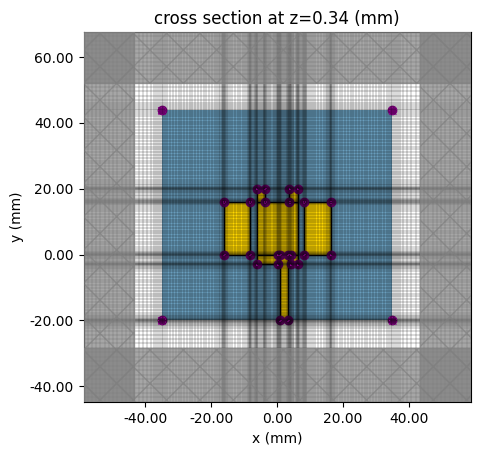

In [19]:
num_passive_radiators = 2

# set an initial width and height for the central patch
patch_init_width = 12.45 * mm
patch_init_height = 16 * mm
patch_init_wh = anp.array([patch_init_width, patch_init_height])

# set the min/max for the patch width and height
patch_min_width = 8 * mm
patch_min_height = 8 * mm
patch_max_width = 18 * mm
patch_max_height = 24 * mm

# set min/max patch dimensions for the central and all surrounding patches
min_patch_dimensions_mm = sum(
    [[patch_min_width, patch_min_height] for idx in range(0, num_passive_radiators + 1)], []
)
max_patch_dimensions_mm = sum(
    [[patch_max_width, patch_max_height] for idx in range(0, num_passive_radiators + 1)], []
)

# set min/max gap between central patch and each surrounding patch
min_gap_mm = [0.5 * mm for idx in range(0, num_passive_radiators)]
max_gap_mm = [5 * mm for idx in range(0, num_passive_radiators)]

# set min/max offset of each surrounding patch center relative to the central patch center
min_offset_mm = [-10 * mm for idx in range(0, num_passive_radiators)]
max_offset_mm = [10 * mm for idx in range(0, num_passive_radiators)]

# set the min/max of the patch inset (i.e. - how much the central patch surrounds the feed line)
max_patch_inset = 6 * mm
min_patch_inset = 1 * mm

# set the min/max of the inset height and the gap between the feed line and the inset
min_inset_height = 1 * mm
max_inset_height = 6 * mm
min_inset_gap = 0.5 * mm
max_inset_gap = 2.0 * mm

min_inset = [min_inset_height, min_inset_height, min_inset_gap, min_inset_gap]
max_inset = [max_inset_height, max_inset_height, max_inset_gap, max_inset_gap]

# set the min/max of the fin widths and heights at the top of the central patch
min_fin_width = 1 * mm
max_fin_width = 6 * mm
min_fin_height = 1 * mm
max_fin_height = 6 * mm

min_fin = [min_fin_width, min_fin_height, min_fin_width, min_fin_height]
max_fin = [max_fin_width, max_fin_height, max_fin_width, max_fin_height]

# combine all the min/max values into clipping arrays to use in the optimization
clip_min_values = min_patch_dimensions_mm + min_gap_mm + min_offset_mm + min_inset + min_fin
clip_max_values = max_patch_dimensions_mm + max_gap_mm + max_offset_mm + max_inset + max_fin

# set initial passive patch sizes
min_dim_avg = 0.5 * (patch_min_width + patch_min_height)
init_passive_wh = [
    min_dim_avg,
    0.5 * (patch_min_height + patch_max_height),
    min_dim_avg,
    0.5 * (patch_min_height + patch_max_height),
]

# set the initial passive patch gaps to the central patch
init_gap_sizes = [2 * mm for idx in range(0, num_passive_radiators)]

# set the initial passive patch offsets to the fixed central patch center
init_offset_coord_locations = [0.5 * patch_init_wh[1], 0.5 * patch_init_wh[1]]

# start the central patch at the same initial width/height as in the single patch case
init_central = list(patch_init_wh.copy())

# collect all the passive parameters
init_passive = init_passive_wh + init_gap_sizes + init_offset_coord_locations

# initialize inset heights and gaps
init_inset_height = 3 * mm
init_inset_gap = 0.75 * mm
init_inset = [init_inset_height, init_inset_height, init_inset_gap, init_inset_gap]

# initialize fin widths and heights
init_fin_width = 2.5 * mm
init_fin_height = 4 * mm
init_fin = [init_fin_width, init_fin_height, init_fin_width, init_fin_height]

# combine the initial parameters together
init_params = init_central + init_passive + init_inset + init_fin

assert num_passive_radiators == 2, (
    "The multi patch optimization is set up specifically for 2 passive radiators."
)


def params_to_boxes(params):
    """
    Unpack the multi-patch optimization parameters into patch geometries for the central
    patch and the surrounding passive radiating patches.
    """
    inset_height_left = params[-8]
    inset_height_right = params[-7]
    inset_gap_left = params[-6]
    inset_gap_right = params[-5]

    fin_left_width = params[-4]
    fin_left_height = params[-3]
    fin_right_width = params[-2]
    fin_right_height = params[-1]

    num_params_wh_central = 2
    wh_central = params[0:num_params_wh_central]

    wh_passive_params = params[num_params_wh_central:]
    num_params_wh_passive = 2

    wh_passive = []
    for idx in range(0, num_passive_radiators):
        wh_passive.append(
            wh_passive_params[num_params_wh_passive * idx : num_params_wh_passive * (idx + 1)]
        )

    gap_params = wh_passive_params[num_params_wh_passive * num_passive_radiators :]
    gaps = gap_params[0:num_passive_radiators]

    offset_params = gap_params[num_passive_radiators:]
    offset_coords = offset_params[0:num_passive_radiators]

    left_central = -0.5 * wh_central[0]
    right_central = 0.5 * wh_central[0]

    left_passive_patch_idx = 0
    right_passive_patch_idx = 1

    left_passive_right = left_central - gaps[left_passive_patch_idx]
    left_passive_left = left_passive_right - wh_passive[left_passive_patch_idx][0]
    left_passive_bottom = (
        offset_coords[left_passive_patch_idx] - 0.5 * wh_passive[left_passive_patch_idx][1]
    )
    left_passive_top = (
        offset_coords[left_passive_patch_idx] + 0.5 * wh_passive[left_passive_patch_idx][1]
    )

    right_passive_left = right_central + gaps[right_passive_patch_idx]
    right_passive_right = right_passive_left + wh_passive[right_passive_patch_idx][0]
    right_passive_bottom = (
        offset_coords[right_passive_patch_idx] - 0.5 * wh_passive[right_passive_patch_idx][1]
    )
    right_passive_top = (
        offset_coords[right_passive_patch_idx] + 0.5 * wh_passive[right_passive_patch_idx][1]
    )

    inset_left = td.Box.from_bounds(
        [-0.5 * wh_central[0], -inset_height_left, sub_z / 2.0],
        [feed_offset - 0.5 * feed_x - inset_gap_left, 0.0, sub_z / 2.0],
    )

    inset_right = td.Box.from_bounds(
        [feed_offset + 0.5 * feed_x + inset_gap_right, -inset_height_right, sub_z / 2.0],
        [0.5 * wh_central[0], 0, sub_z / 2.0],
    )

    fin_left = td.Box.from_bounds(
        [-0.5 * wh_central[0], wh_central[1], sub_z / 2.0],
        [-0.5 * wh_central[0] + fin_left_width, wh_central[1] + fin_left_height, sub_z / 2.0],
    )

    fin_right = td.Box.from_bounds(
        [0.5 * wh_central[0] - fin_right_width, wh_central[1], sub_z / 2.0],
        [0.5 * wh_central[0], wh_central[1] + fin_right_height, sub_z / 2.0],
    )

    boxes = [
        # central patch
        td.Box.from_bounds(
            [-0.5 * wh_central[0], 0, sub_z / 2], [0.5 * wh_central[0], wh_central[1], sub_z / 2]
        ),
        # inset patches
        inset_left,
        inset_right,
        # fin patches
        fin_left,
        fin_right,
        # passive patches
        td.Box.from_bounds(
            [left_passive_left, left_passive_bottom, sub_z / 2],
            [left_passive_right, left_passive_top, sub_z / 2],
        ),
        td.Box.from_bounds(
            [right_passive_left, right_passive_bottom, sub_z / 2],
            [right_passive_right, right_passive_top, sub_z / 2],
        ),
    ]

    return boxes


# plot the patch and mesh of the initial structure to visually inspect geometry before starting optimization
plot_structures_and_mesh(params_to_boxes(init_params))

## Running the Multi-Patch Optimization

Now we set up and run the optimization. We first compute the initial Poynting flux which serves as the normalization baseline in the objective function. When computing these initial values, we log the simulation cost to give an idea of how many FlexCredits it costs to run. During the optimization loop, each iteration we compute the gradient, which requires two simulations. The cost per iteration will thus be double that of a single simulation except for the occasional iteration where we save additional simulation data for evaluation after the optimization.

In [20]:
# Turn the logging level to only show errors to not crowd the optimization output with repeated warnings
td.config.logging_level = "ERROR"

# whether or not to restart the optimization from the current saved checkpoint
restart_optimization = True  # False
restart_fname = "misc/rf_autograd_2_multi_patch_opt_state.pkl"

# compute initial poynting flux to be used in the objective function
# initial_poynting_flux, initial_s11 = compute_poynting_and_s11(
#     init_params, log_simulation_cost=True
# )

We run the optimization and capture the figure of merit, `S11`, and gain metrics along the way.

In [22]:
# Set up the objective function for the multi patch optimization. Using autograd, we can find
# the gradient of the objective function with respect to the first argument, which contains all
# 18 parameters describing the multi-patch antenna geometry.
obj_val_and_grad = value_and_grad(objective_fn, argnum=[0])

# initialize patch parameters
patch_params = anp.array(init_params.copy())

# set up optimization parameters and optimizer
learning_rate = 30
optimizer = optax.adam(learning_rate=learning_rate)
opt_state = optimizer.init(patch_params)

num_steps = 70

full_eval_period = 10
s11_sq_dB_evolution = []
s11_f_ghz = None
realized_gain_evolution = []

figure_of_merit = np.zeros(num_steps + 1)


def pack_optimization_state(iter_idx):
    optimization_state["iteration"] = iter_idx
    optimization_state["figure of merit"] = figure_of_merit
    optimization_state["realized gain evolution"] = realized_gain_evolution
    optimization_state["opt state"] = opt_state
    optimization_state["patch parameters"] = patch_params


optimization_state = {}
if not os.path.exists(restart_fname):
    pack_optimization_state(iter_idx=0)

if restart_optimization:
    with open(restart_fname, "rb") as file:
        optimization_state = pickle.load(file)

start_idx = 0
if restart_optimization:
    start_idx = optimization_state["iteration"]
    figure_of_merit = optimization_state["figure of merit"]
    realized_gain_evolution = optimization_state["realized gain evolution"]
    opt_state = optimization_state["opt state"]
    patch_params = optimization_state["patch parameters"]

    if (num_steps + 1) > len(figure_of_merit):
        figure_of_merit = np.pad(figure_of_merit, ((0, num_steps + 1 - len(figure_of_merit))))

# run optimization loop, updating the patch parameters with the `Adam` optimizer
# at each step and clipping the design on the bounds
for step_idx in range(start_idx, num_steps):
    pack_optimization_state(iter_idx=step_idx)
    with open(restart_fname, "wb") as file:
        pickle.dump(optimization_state, file)

    f, g = obj_val_and_grad(patch_params, initial_poynting_flux)

    figure_of_merit[step_idx] = float(f)

    if (step_idx % full_eval_period) == 0:
        smatrix_data_eval, realized_gain_eval = evaluate_antenna(patch_params, freqs_s_params)
        smatrix_eval = smatrix_data_eval.smatrix()
        smatrix_f_ghz = smatrix_eval.data.coords["f"] / 1e9
        s11_f_ghz = smatrix_f_ghz.copy()
        s11_data_selection = smatrix_eval.data.isel(port_out=0, port_in=0)
        s11_sq_dB_evolution.append(20 * np.log10(np.abs(s11_data_selection.values.flatten())))

        realized_gain_evolution.append(
            {
                "Gtheta": realized_gain_eval["Gtheta"]
                .sel(phi=0, method="nearest")
                .squeeze()
                .values,
                "Gphi": realized_gain_eval["Gphi"].sel(phi=0, method="nearest").squeeze().values,
            }
        )

    updates, opt_state = optimizer.update(-g[0], opt_state, patch_params)

    patch_params = optax.apply_updates(patch_params, updates)
    patch_params = anp.array(patch_params)
    patch_params = anp.clip(patch_params, a_min=clip_min_values, a_max=clip_max_values)

    if (step_idx % print_iteration_frequency) == 0:
        # We don't print all of the optimization parameters below to reduce clutter
        output_text = Text.assemble(
            (f"Iteration {step_idx + 1}", "bold cyan"),
            "\n",
            (f"\tFigure of merit: ", "bold"),
            (f"{f:.{print_decimal_places}f}", "bold green"),
        )
        console.print(output_text)

figure_of_merit[num_steps] = objective_fn(patch_params, initial_poynting_flux)

14:47:42 EST ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

             ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

             ERROR: If the 'ModeSimulation' geometry is not planar, then 'plane'
             must be specified.                                                 

             ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

Iteration 41
        Figure of merit: 14.17

...

Iteration 66
        Figure of merit: 33.48

16:40:02 EST ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

             ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

             ERROR: If the 'ModeSimulation' geometry is not planar, then 'plane'
             must be specified.                                                 

             ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

After the optimization, we can plot the figure of merit and compare the optimized antenna geometry to the initial antenna geometry. We can see that the optimization made a significant amount of changes to the antenna structure to realize dual-band operation. We also plot the evolution of the `S11` parameter and realized gain throughout the optimization.

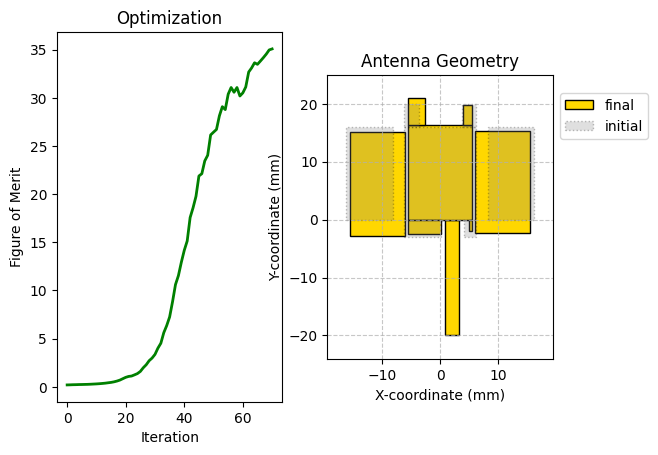

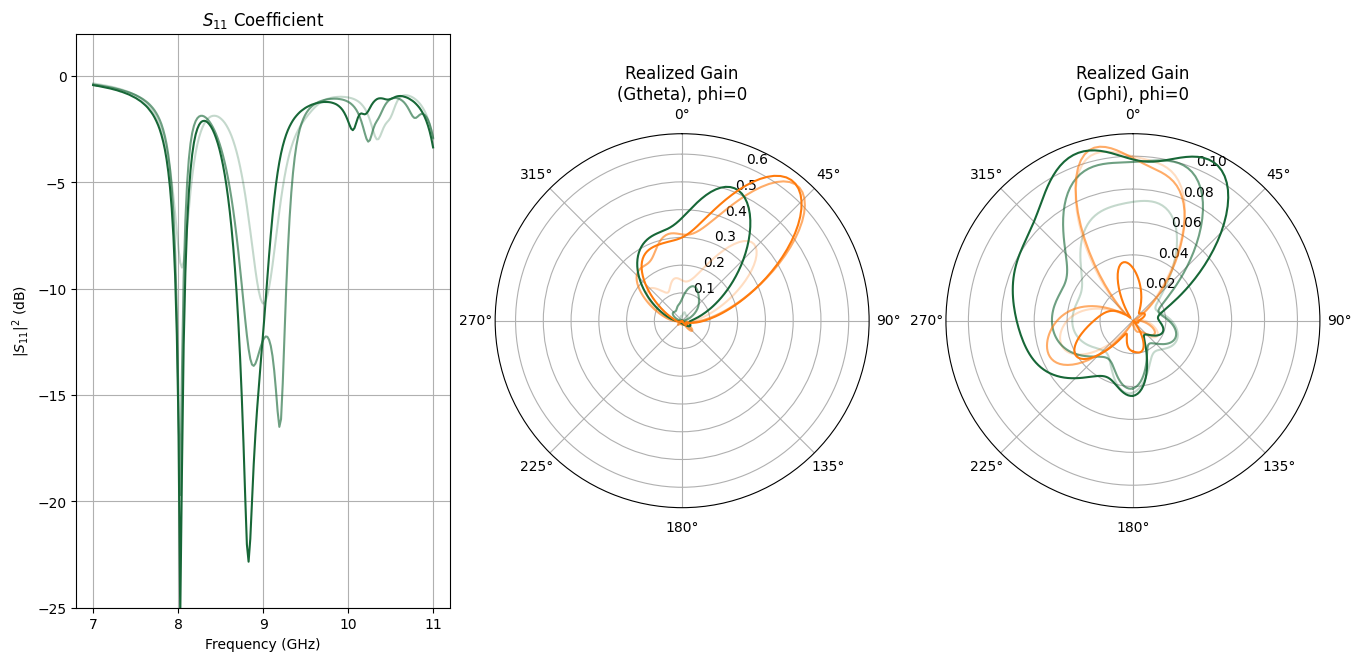

In [23]:
# Plot the results of the optimization including the optimization trajectory and the resulting geometry of the
# central and surrounding patches compared to the initial state
plot_optimization_results(
    figure_of_merit,
    td.Box(center=(feed_offset, -0.5 * feed_y, 0.0), size=(feed_x, feed_y, 0.0)),
    params_to_boxes(init_params),
    params_to_boxes(patch_params),
)

# Plot the evolution of the antenna S11 and realized gain during the course of the optimization
plot_antenna_evolution(
    s11_sq_dB_evolution,
    s11_f_ghz,
    realized_gain_evolution,
    opt_freqs,
)

We can also compare the `S11` and realized gain for the final optimization state with that of the initial state. On the `S11` plot, we indicate the frequencies that were optimized for. We can see a significant improvement from the `S11` spectrum and realized gain at both optimization frequencies.

17:10:55 EST ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

             ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

             ERROR: If the 'ModeSimulation' geometry is not planar, then 'plane'
             must be specified.                                                 

             ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

17:16:45 EST ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

             ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

             ERROR: If the 'ModeSimulation' geometry is not planar, then 'plane'
             must be specified.                                                 

             ERROR: 'HeatSimulation' does not currently support structures with 
             dimensions of zero size ('structures[1]').                         

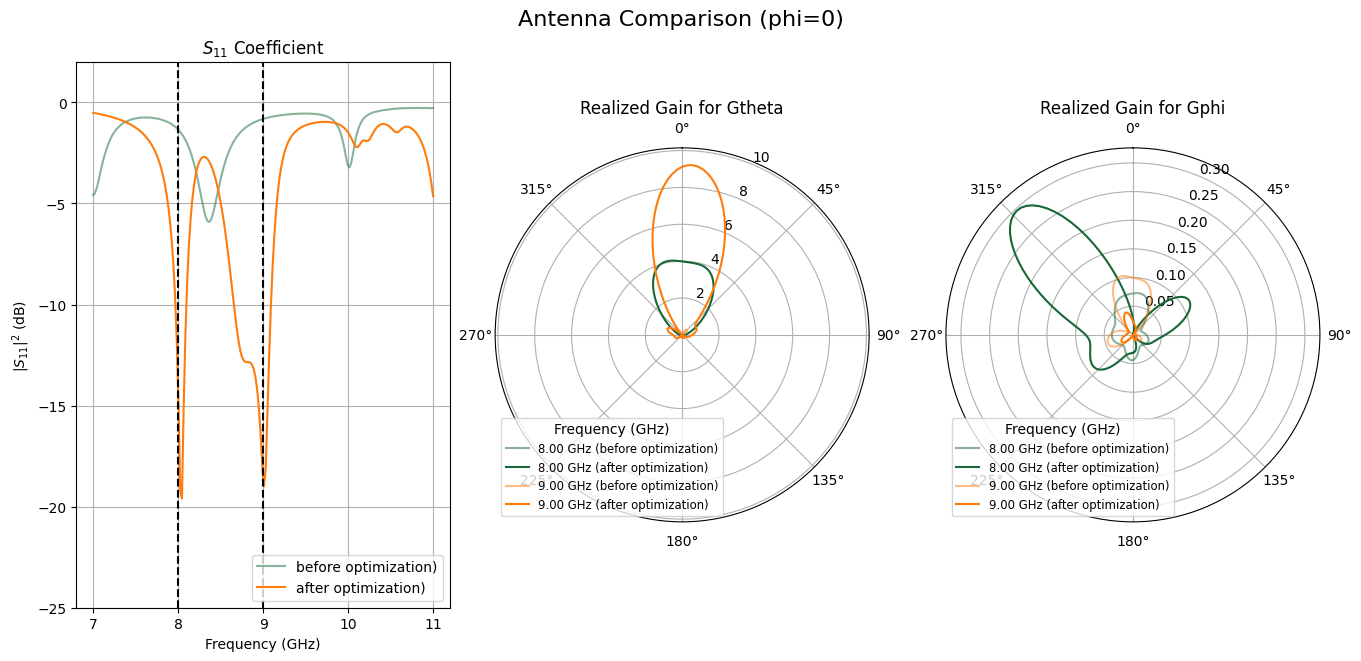

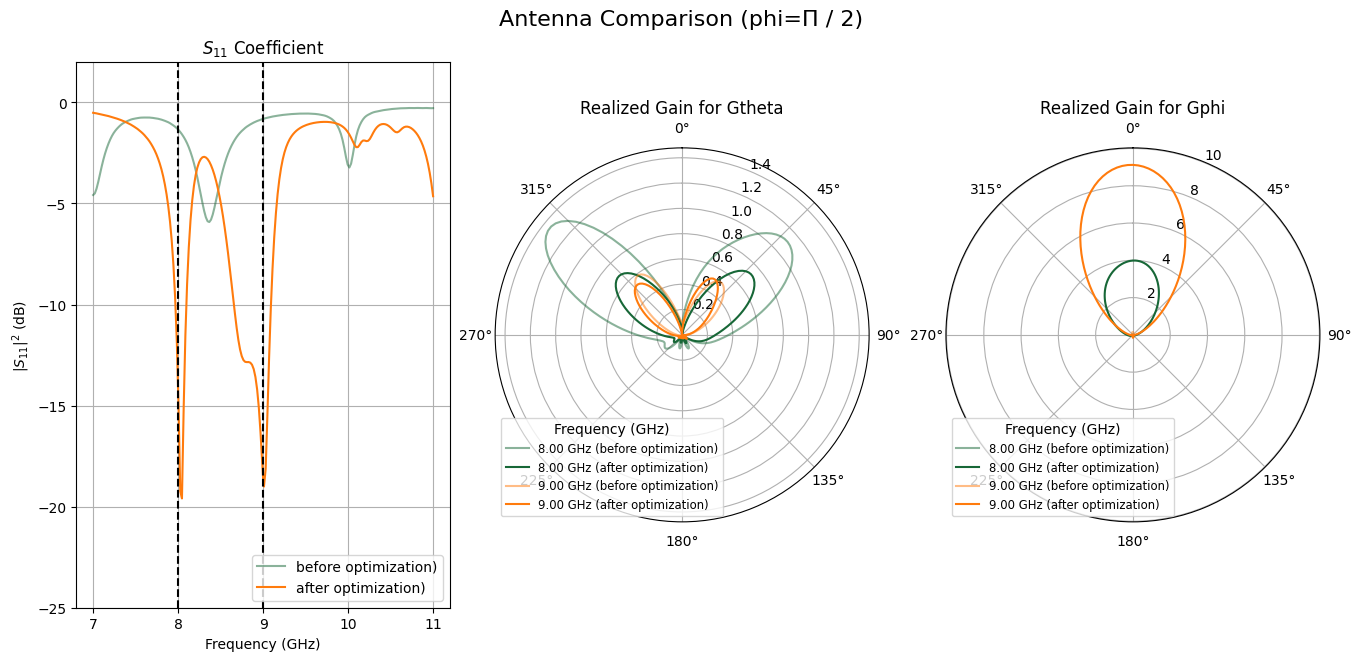

In [24]:
# compute S11 and realized gain for the initial multi patch geometry
smatrix_data_init, realized_gain_init = evaluate_antenna(init_params, freqs_s_params)
# compute S11 and realized gain for the optimized multi patch geometry
smatrix_data_final, realized_gain_final = evaluate_antenna(patch_params, freqs_s_params)

# plot the comparison in S11 and gain for the initial and optimized antennas for phi=0
plot_phi = 0.0
plot_antenna_comparison(
    [smatrix_data_init.smatrix(), smatrix_data_final.smatrix()],
    [smatrix_data_init.data, smatrix_data_final.data],
    [realized_gain_init, realized_gain_final],
    plot_phi,
    sim_names=["before optimization", "after optimization"],
    plot_title="Antenna Comparison (phi=0)",
)

# plot the comparison in S11 and gain for the initial and optimized antennas for phi=pi / 2
plot_phi = np.pi / 2.0
plot_antenna_comparison(
    [smatrix_data_init.smatrix(), smatrix_data_final.smatrix()],
    [smatrix_data_init.data, smatrix_data_final.data],
    [realized_gain_init, realized_gain_final],
    plot_phi,
    sim_names=["before optimization", "after optimization"],
    plot_title="Antenna Comparison (phi=\u03a0 / 2)",
)

# Save results of optimization
np.save("misc/rf_autograd_2_multi_patch_antenna_optimization.npy", patch_params)

By expanding from a 2-parameter single patch to an 18-parameter multi-patch design, we have demonstrated how the adjoint method scales to handle significantly more complex antenna optimization problems. The dual-band result would be difficult to achieve through manual tuning or parameter sweeps alone. This workflow can be extended further to even more complex antenna topologies and multi-objective targets.